#### Fig. 1g-h

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os 
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import math
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 12,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 12,  # Title size for axes
    'xtick.labelsize': 12,  # X-tick label size
    'ytick.labelsize': 12,  # Y-tick label size
    'legend.fontsize': 12,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})



In [4]:
group_dict = {
    "Epithelial" : ["AT0", "AT1", "AT2", "Multiciliated (non-nasal)", "pre-TB secretory"],
    "Stroma" : ["Adventitial fibroblasts","Alveolar fibroblasts", "Myofibroblasts", "Peribronchial fibroblasts", "Pericytes",
                "Smooth muscle", "Smooth muscle FAM83D+", "Subpleural fibroblasts"],
    "Immune" : ["Alveolar Mph CCL3+","Alveolar macrophages", "B cells", "CD4 T cells",
                "CD8 T cells", "Interstitial Mph perivascular", "Mast cells", "Monocyte-derived Mph", "NK cells", "Plasma cells", "T cells proliferating"],
    "Endothelial" : ["EC aerocyte capillary", "EC arterial", "EC general capillary", "EC venous pulmonary", 
                     "EC venous systemic", "Lymphatic EC differentiating", "Lymphatic EC mature"]

}

In [5]:
cell_type_order = [celltype for group in group_dict.values() for celltype in group]

In [6]:
save_dir = "f2_ann_finest_level"
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

In [7]:
# load adata
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/h5ad/adata_vis_assigned_cell_types_ann_finest_level.h5ad")

In [8]:
adata_vis

AnnData object with n_obs × n_vars = 160702 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT0', 'AT1', 'AT2', 'AT2 proliferating', 'Adventitial fibroblasts', 'Alveolar Mph CCL3+', 'Alveolar Mph M

In [9]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_vis)
# Logarithmize the data
sc.pp.log1p(adata_vis)

sc.pp.highly_variable_genes(adata_vis)
sc.pp.scale(adata_vis)
sc.tl.pca(adata_vis)

In [10]:
adata_vis.var_names

Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15',
       'AGRN', 'RNF223', 'C1orf159',
       ...
       'MT-CO1', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=16959)

In [11]:
from matplotlib.patches import Rectangle

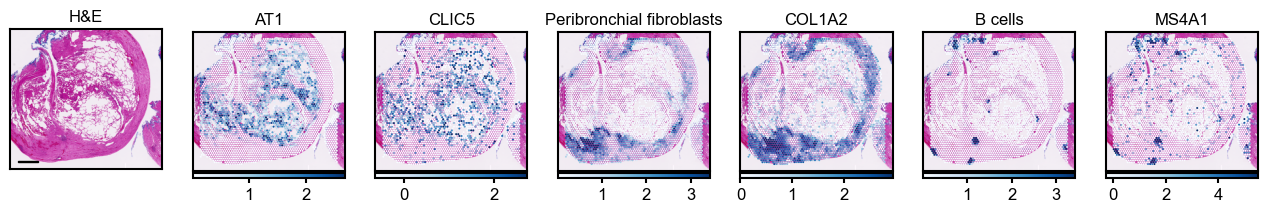

In [12]:
n_rows, n_cols = 1, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['18_57617_A1']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)


sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:], 
    cmap='Blues',
    library_id = "18_57617_A1",
    size=1.3,
    ax = axes[0],
    #color = "AT2",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    show=False)
axes[0].set_title("H&E", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:], 
    cmap='Blues',
    library_id = "18_57617_A1",
    size=1.3,
    ax = axes[1],
    color="AT1", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[1].set_title("AT1", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:], 
    cmap='Blues',
    library_id = "18_57617_A1",
    size=1.3,
    ax = axes[2],
    color="CLIC5", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[2].set_title("CLIC5", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:], 
    cmap='Blues',
    library_id = "18_57617_A1",
    size=1.3,
    ax = axes[3],
    color="Peribronchial fibroblasts", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[3].set_title("Peribronchial fibroblasts", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:], 
    cmap='Blues',
    library_id = "18_57617_A1",
    size=1.3,
    ax = axes[4],
    color="COL1A2", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[4].set_title("COL1A2", fontsize = 12, pad = 5)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:], 
    cmap='Blues',
    library_id = "18_57617_A1",
    size=1.3,
    ax = axes[5],
    color="B cells", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[5].set_title("B cells", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "18_57617_A1" ,:], 
    cmap='Blues',
    library_id = "18_57617_A1",
    size=1.3,
    ax = axes[6],
    color="MS4A1", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[6].set_title("MS4A1", fontsize = 12, pad = 5)



for axis in axes:
    axis.set_xlabel("")
    axis.set_ylabel("")

#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.5)
plt.savefig(os.path.join(save_dir,"spatial_plot_cell_types_ipf_genes.pdf"), bbox_inches = "tight")


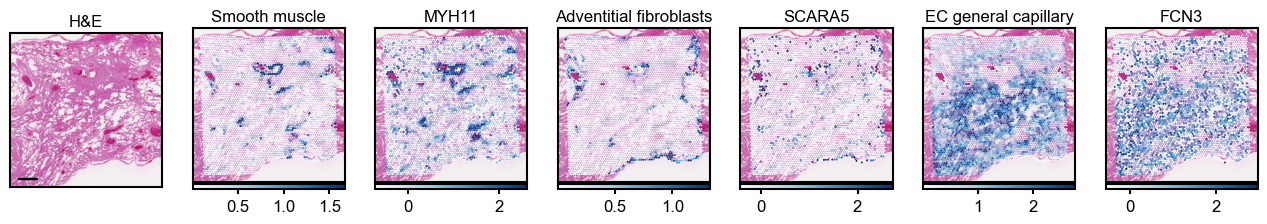

In [13]:
n_rows, n_cols = 1, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['19_35057_C3']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)



sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "19_35057_C3" ,:], 
    cmap='Blues',
    library_id = "19_35057_C3",
    size=1.3,
    ax = axes[0],
    #color = "AT2",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    show=False)
axes[0].set_title("H&E", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "19_35057_C3" ,:], 
    cmap='Blues',
    library_id = "19_35057_C3",
    size=1.3,
    ax = axes[1],
    color="Smooth muscle", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[1].set_title("Smooth muscle", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "19_35057_C3" ,:], 
    cmap='Blues',
    library_id = "19_35057_C3",
    size=1.3,
    ax = axes[2],
    color="MYH11", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[2].set_title("MYH11", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "19_35057_C3" ,:], 
    cmap='Blues',
    library_id = "19_35057_C3",
    size=1.3,
    ax = axes[3],
    color="Adventitial fibroblasts", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[3].set_title("Adventitial fibroblasts", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "19_35057_C3" ,:], 
    cmap='Blues',
    library_id = "19_35057_C3",
    size=1.3,
    ax = axes[4],
    color="SCARA5", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[4].set_title("SCARA5", fontsize = 12, pad = 5)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "19_35057_C3" ,:], 
    cmap='Blues',
    library_id = "19_35057_C3",
    size=1.3,
    ax = axes[5],
    color="EC general capillary", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01   ', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[5].set_title("EC general capillary", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "19_35057_C3" ,:], 
    cmap='Blues',
    library_id = "19_35057_C3",
    size=1.3,
    ax = axes[6],
    color="FCN3", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[6].set_title("FCN3", fontsize = 12, pad = 5)



for axis in axes:
    axis.set_xlabel("")
    axis.set_ylabel("")

#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0)
plt.savefig(os.path.join(save_dir,"spatial_plot_cell_types_nsip_genes.pdf"), bbox_inches = 'tight',transparent = True)


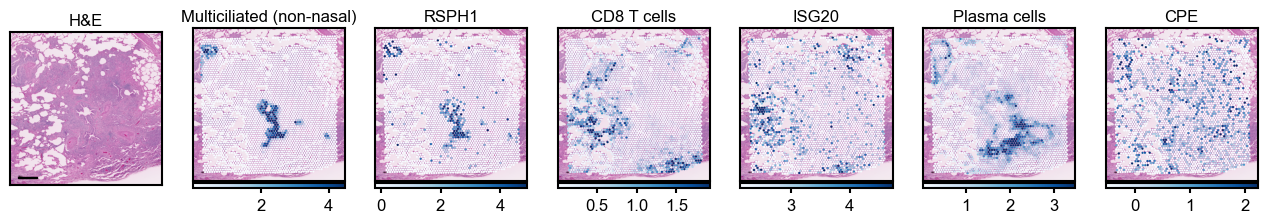

In [14]:
n_rows, n_cols = 1, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['21_57231_A3']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar 

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_57231_A3" ,:], 
    cmap='Blues',
    library_id = "21_57231_A3",
    size=1.3,
    ax = axes[0],
    #color = "AT2",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    show=False)
axes[0].set_title("H&E", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_57231_A3" ,:], 
    cmap='Blues',
    library_id = "21_57231_A3",
    size=1.3,
    ax = axes[1],
    color="Multiciliated (non-nasal)", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[1].set_title("Multiciliated (non-nasal)", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_57231_A3" ,:], 
    cmap='Blues',
    library_id = "21_57231_A3",
    size=1.3,
    ax = axes[2],
    color="RSPH1", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[2].set_title("RSPH1", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_57231_A3" ,:], 
    cmap='Blues',
    library_id = "21_57231_A3",
    size=1.3,
    ax = axes[3],
    color="CD8 T cells", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[3].set_title("CD8 T cells", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_57231_A3" ,:], 
    cmap='Blues',
    library_id = "21_57231_A3",
    size=1.3,
    ax = axes[4],
    color="ISG20", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p70', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[4].set_title("ISG20", fontsize = 12, pad = 5)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_57231_A3" ,:], 
    cmap='Blues',
    library_id = "21_57231_A3",
    size=1.3,
    ax = axes[5],
    color="Plasma cells", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p01', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[5].set_title("Plasma cells", fontsize = 12, pad = 5)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_57231_A3" ,:], 
    cmap='Blues',
    library_id = "21_57231_A3",
    size=1.3,
    ax = axes[6],
    color="CPE", 
    # limit color scale at 99.2% quantile of cell abundance
    vmin='p30', vmax='p99',colorbar_loc="bottom",
    show=False)
axes[6].set_title("CPE", fontsize = 12, pad = 5)



for axis in axes:
    axis.set_xlabel("")
    axis.set_ylabel("")
# After plotting

#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0)
plt.savefig(os.path.join(save_dir,"spatial_plot_cell_types_chp_genes.pdf"), bbox_inches = "tight", transparent = True)
